# 🚴 Berlin Bicycle Accident Analysis
### Capstone Project — Data Science Bootcamp

**Goal:** Analyze 8 years of official German traffic accident data (2018–2025) to identify risk patterns for cyclists in Berlin and build a machine learning model to predict accident severity.

**Data source:** [Unfallatlas](https://unfallatlas.statistikportal.de) — Federal Statistical Office of Germany  
**Scope:** 37,948 bicycle accidents in Berlin across 12 districts  
**Tech stack:** `pandas` · `seaborn` · `folium` · `XGBoost` · `OSMnx` · `Streamlit`

---

## Table of Contents
1. [Data Loading & Merging](#1-data-loading)
2. [Filtering & Cleaning](#2-filtering)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Collision Partner Analysis](#4-collision)
5. [Temporal Analysis](#5-temporal)
6. [District Risk Analysis](#6-district)
7. [Geospatial Heatmap](#7-heatmap)


---
## 1. Data Loading & Merging <a id='1-data-loading'></a>

We load 10 years of Unfallatlas CSV/TXT files (2016–2025), excluding auxiliary `LinRef` geometry files. Each file covers one calendar year for all of Germany.


In [3]:
import glob
import os
import pandas as pd

folder_path = "data"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

# Exclude LinRef geometry files and any previously generated output files
all_file_paths = [
    f for f in csv_files + txt_files
    if "LinRef" not in f and "berlin" not in f.lower()
]
column_mapping = {
    # Road conditions — 3 different names across years
    "IstStrasse":         "STRZUSTAND",
    "STRZUSTAND":         "STRZUSTAND",
    "IstStrassenzustand": "STRZUSTAND",
    
    # Light conditions
    "LICHT":              "ULICHTVERH",
    
    # Other mappings
    "IstSonstig":         "IstSonstige",
    "UIDENTSTLAE":        "UIDENTSTLA",
    "ï»¿UIDENTSTLAE":    "UIDENTSTLA",
    "ï»¿OID_":            "OID_",
    "OBJECTID_1":         "OBJECTID",
    "ï»¿UJAHR":           "UJAHR",
    "ujahr":              "UJAHR",
    "ï»¿ISTRAD":          "IstRad",
    "istrad":             "IstRad",
    "ISTRAD":             "IstRad",
}
df_list = []

for file_path in all_file_paths:
    file_name = os.path.basename(file_path)
    try:
        # Fixed: removed low_memory=False to prevent Python engine conflict
        temp_df = pd.read_csv(
            file_path, sep=None, engine="python", encoding="latin-1"
        )

        # Standardize column names
        temp_df = temp_df.rename(columns=column_mapping)
        temp_df["source_file"] = file_name

        df_list.append(temp_df)

        # Check year information
        year_info = (
            temp_df["UJAHR"].unique().tolist()
            if "UJAHR" in temp_df.columns
            else "No Year Column!"
        )
        print(f"✅ {file_name} — {len(temp_df)} rows — Year: {year_info}")

    except Exception as e:
        print(f"❌ {file_name} — ERROR: {e}")

# Merge all DataFrames
df= pd.concat(df_list, ignore_index=True)

# Clean Year column
if "UJAHR" in df.columns:
    df["UJAHR"] = (
        df["UJAHR"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
    )

print("\n" + "=" * 45)

print(f"\n✅ Data merged and columns standardized successfully!")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"Merged Years: {sorted(df['UJAHR'].unique())}")
print("=" * 45)




✅ Unfallorte2024.csv — 268519 rows — Year: [2024]
✅ Unfallorte_2025.csv — 273007 rows — Year: [2025]
✅ Unfallorte2023.csv — 269048 rows — Year: [2023]
✅ Unfallorte2022.csv — 256492 rows — Year: [2022]
✅ Unfallorte2020.csv — 237994 rows — Year: [2020]
✅ Unfallorte2017.txt — 195229 rows — Year: [2017]
✅ Unfallorte.txt — 151673 rows — Year: [2016]
✅ Unfallorte_2021.txt — 238826 rows — Year: [2021]
✅ Unfallorte2019.txt — 268370 rows — Year: [2019]
✅ Unfallorte2018.txt — 211868 rows — Year: [2018]


✅ Data merged and columns standardized successfully!
Total Rows: 2371026
Total Columns: 29
Merged Years: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


---
## 2. Filtering & Cleaning <a id='2-filtering'></a>

We apply two filters to isolate our target population:
- **`IstRad == 1`** — accidents involving at least one bicycle
- **`ULAND == 11`** — federal state code for Berlin

> **Note:** Berlin only appears in the dataset from 2018 onwards — prior years were not submitted to the Unfallatlas system.


In [7]:
# Filter: bicycle accidents only
df_combined = df[df['IstRad'] == 1]
print(f"Total bicycle accidents (Germany): {len(df_combined):,}")

# Filter: Berlin (ULAND = 11)
df_berlin = df_combined[df_combined['ULAND'] == 11]
print(f"Berlin bicycle accidents:          {len(df_berlin):,}")

print("\nAccidents per year in Berlin:")
print(df_berlin['UJAHR'].value_counts().sort_index())

print("\nAccident severity distribution (UKATEGORIE):")
print(df_berlin['UKATEGORIE'].value_counts().rename({1:'Fatal', 2:'Serious injury', 3:'Minor injury'}))


Total bicycle accidents (Germany): 716,365
Berlin bicycle accidents:          37,948

Accidents per year in Berlin:
UJAHR
2018    5192
2019    5005
2020    5109
2021    4293
2022    4658
2023    4472
2024    4452
2025    4767
Name: count, dtype: int64

Accident severity distribution (UKATEGORIE):
UKATEGORIE
Minor injury      33018
Serious injury     4856
Fatal                74
Name: count, dtype: int64


### 2.1 Column Selection & Renaming

We retain only the 16 columns relevant to our analysis and rename them from German abbreviations to descriptive English names.

| Original | Renamed | Description |
|---|---|---|
| UJAHR | year | Accident year |
| UMONAT | month | Month (1–12) |
| USTUNDE | hour | Hour of day (0–23) |
| UWOCHENTAG | day_of_week | Day of week (1=Sun, 7=Sat) |
| UKATEGORIE | accident_severity | 1=Fatal, 2=Serious, 3=Minor |
| UART | accident_kind | Accident type code |
| UTYP1 | accident_subtype | Accident subtype code |
| ULICHTVERH | light_conditions | 0=Daylight, 1=Dusk, 2=Dark lit, 3=Dark unlit |
| STRZUSTAND | road_conditions | 0=Dry, 1=Wet, 2=Ice/Snow |
| IstPKW | is_car | Car involved (0/1) |
| IstFuss | is_pedestrian | Pedestrian involved (0/1) |
| IstKrad | is_motorcycle | Motorcycle involved (0/1) |
| IstGkfz | is_truck | Heavy vehicle involved (0/1) |
| UKREIS | district_code | Berlin district (1–12) |
| XGCSWGS84 | longitude | WGS84 longitude |
| YGCSWGS84 | latitude | WGS84 latitude |


In [8]:

# Select relevant columns
columns_to_keep = [
    'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG',
    'UKATEGORIE', 'UART', 'UTYP1',
    'ULICHTVERH', 'STRZUSTAND',
    'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz',
    'UKREIS', 'XGCSWGS84', 'YGCSWGS84'
]

df_clean = df_berlin[columns_to_keep].copy()

# Rename to English
df_clean = df_clean.rename(columns={
    'UJAHR': 'year', 'UMONAT': 'month', 'USTUNDE': 'hour',
    'UWOCHENTAG': 'day_of_week', 'UKATEGORIE': 'accident_severity',
    'UART': 'accident_kind', 'UTYP1': 'accident_subtype',
    'ULICHTVERH': 'light_conditions', 'STRZUSTAND': 'road_conditions',
    'IstPKW': 'is_car', 'IstFuss': 'is_pedestrian',
    'IstKrad': 'is_motorcycle', 'IstGkfz': 'is_truck',
    'UKREIS': 'district_code', 'XGCSWGS84': 'longitude', 'YGCSWGS84': 'latitude'
})

# Fix coordinate format (German decimal comma → dot)
for col in ['longitude', 'latitude']:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)

# Add date column
df_clean['date'] = pd.to_datetime(df_clean[['year', 'month']].assign(day=1))

print(f"✅ Clean dataset ready: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_berlin_rad_final = df_clean.copy()
df_berlin_rad_final.head(3)


✅ Clean dataset ready: 37,948 rows × 17 columns
Missing values: 0


,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_car,is_pedestrian,is_motorcycle,is_truck,district_code,longitude,latitude,date
121092,2024,3,10,1,2,5,3,0,0,0,0,0,0.0,7,13.385534,52.470980,2024-03-01
121099,2024,3,9,5,3,5,3,0,1,1,0,0,0.0,2,13.470725,52.514043,2024-03-01
121107,2024,3,7,4,3,5,7,0,0,1,0,0,0.0,4,13.279736,52.509792,2024-03-01


### 2.2 Label Decoding

Numeric codes are mapped to human-readable labels for use in visualizations and analysis.


In [10]:
# Label mappings (Unfallatlas official documentation)
severity_map     = {1: 'fatal', 2: 'serious_injury', 3: 'minor_injury'}
light_map        = {0: 'daylight', 1: 'dusk_dawn', 2: 'dark_lit', 3: 'dark_unlit'}
day_map          = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
                    5:'Thursday', 6:'Friday', 7:'Saturday'}
accident_type_map = {
    1: 'driving_accident', 2: 'turning_crossing', 3: 'turning_pedestrian',
    4: 'stationary_vehicle', 5: 'longitudinal_traffic',
    6: 'other', 7: 'pedestrian_accident'
}
road_map = {0: 'dry', 1: 'wet_damp', 2: 'ice_snow'}
district_names = {
    1: 'Mitte', 2: 'Friedrichshain-Kreuzberg', 3: 'Pankow',
    4: 'Charlottenburg-Wilmersdorf', 5: 'Spandau', 6: 'Steglitz-Zehlendorf',
    7: 'Tempelhof-Schöneberg', 8: 'Neukölln', 9: 'Treptow-Köpenick',
    10: 'Marzahn-Hellersdorf', 11: 'Lichtenberg', 12: 'Reinickendorf'
}

df_berlin_rad_final['severity_label']       = df_berlin_rad_final['accident_severity'].map(severity_map)
df_berlin_rad_final['light_label']          = df_berlin_rad_final['light_conditions'].map(light_map)
df_berlin_rad_final['day_label']            = df_berlin_rad_final['day_of_week'].map(day_map)
df_berlin_rad_final['accident_type_label']  = df_berlin_rad_final['accident_kind'].map(accident_type_map)
df_berlin_rad_final['road_label']           = df_berlin_rad_final['road_conditions'].map(road_map)
df_berlin_rad_final['district_name']        = df_berlin_rad_final['district_code'].map(district_names)

print("Severity distribution:")
print(df_berlin_rad_final['severity_label'].value_counts())
print("\nLight conditions:")
print(df_berlin_rad_final['light_label'].value_counts())
print("\nRoad conditions:")
print(df_berlin_rad_final['road_label'].value_counts())


Severity distribution:
severity_label
minor_injury      33018
serious_injury     4856
fatal                74
Name: count, dtype: int64

Light conditions:
light_label
daylight     30474
dark_lit      5402
dusk_dawn     2072
Name: count, dtype: int64

Road conditions:
road_label
dry         31154
wet_damp     6584
ice_snow      210
Name: count, dtype: int64


In [28]:
df_berlin_rad_final.head(5)

,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_car,...,longitude,latitude,date,severity_label,light_label,day_label,accident_type_label,road_label,district_name,collision_type
121092,2024,3,10,1,2,5,3,0,0,0,...,13.385534,52.470980,2024-03-01,serious_injury,daylight,Sunday,longitudinal_traffic,dry,Tempelhof-Schöneberg,Bicycle Only
121099,2024,3,9,5,3,5,3,0,1,1,...,13.470725,52.514043,2024-03-01,minor_injury,daylight,Thursday,longitudinal_traffic,wet_damp,Friedrichshain-Kreuzberg,Bicycle + Car
121107,2024,3,7,4,3,5,7,0,0,1,...,13.279736,52.509792,2024-03-01,minor_injury,daylight,Wednesday,longitudinal_traffic,dry,Charlottenburg-Wilmersdorf,Bicycle + Car
121109,2024,3,17,4,3,3,6,0,0,0,...,13.457936,52.492031,2024-03-01,minor_injury,daylight,Wednesday,turning_pedestrian,dry,Treptow-Köpenick,Bicycle Only
121110,2024,3,12,4,3,5,2,0,0,0,...,13.387188,52.440151,2024-03-01,minor_injury,daylight,Wednesday,longitudinal_traffic,dry,Tempelhof-Schöneberg,Bicycle Only


---
## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

### 3.1 Monthly Time Series (2018–2025)

We plot accident counts over time to identify seasonal patterns and long-term trends.


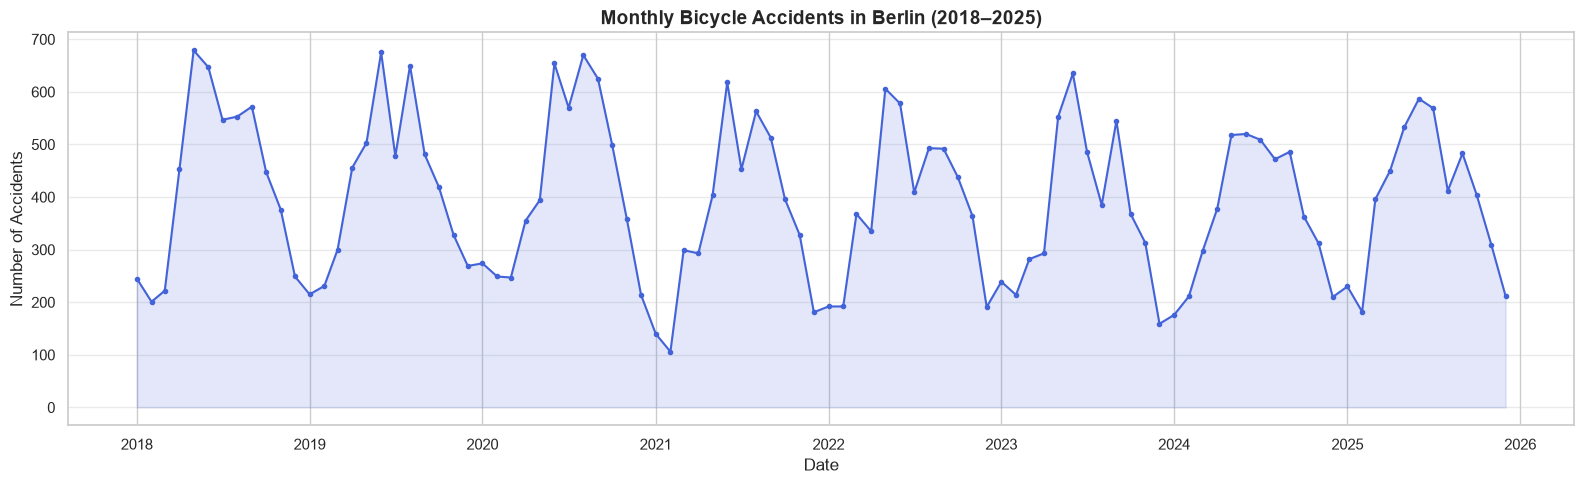

        date  accident_count
0 2018-01-01             245
1 2018-02-01             201
2 2018-03-01             222
3 2018-04-01             453
4 2018-05-01             679


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Year + Month to datetime format (defaulting to the 1st of each month)
df_berlin_rad_final['date'] = pd.to_datetime(
    df_berlin_rad_final[['year', 'month']].assign(day=1)
)

# Aggregate monthly accident counts (Monthly Time Series)
monthly_ts = (
    df_berlin_rad_final.groupby('date')
    .size()
    .reset_index(name='accident_count')
)

# Plotting the Time Series
plt.figure(figsize=(16, 5))
plt.plot(monthly_ts['date'], monthly_ts['accident_count'], 
         color='#4363d8', linewidth=1.5, marker='o', markersize=3)
plt.fill_between(monthly_ts['date'], monthly_ts['accident_count'], 
                 alpha=0.15, color='#4363d8')

plt.title('Monthly Bicycle Accidents in Berlin (2018–2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

# Save and show plot
plt.savefig('berlin_accidents_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# Display first few rows of the aggregated dataset
print(monthly_ts.head())

### 3.2 Accidents by Month & Year

Yearly comparison reveals consistent summer peaks (May–August) across all years, confirming that accident frequency is strongly driven by cycling season rather than year-over-year changes.


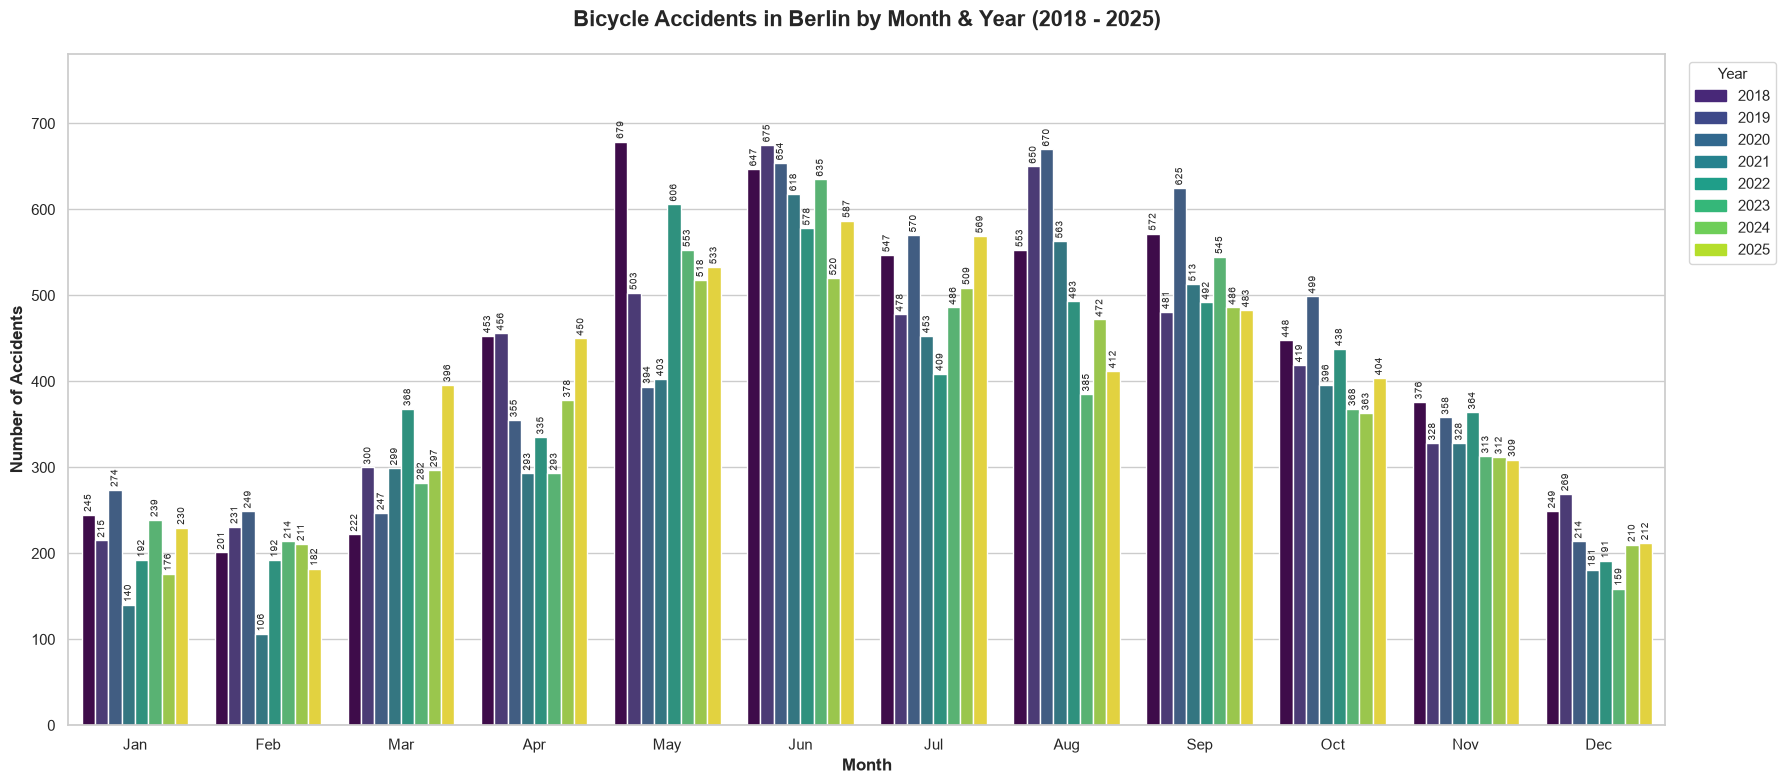

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch # Manuel lejant için gerekli

# 1. DATA CLEANING & YEAR CONVERSION
df_plot = df_berlin_rad_final.copy()

# Ensure year is strictly integer (converts string, float .0, etc.)
df_plot["year"] = pd.to_numeric(df_plot["year"], errors='coerce').fillna(0).astype(int)

# Map month numbers to month names
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_names = {i + 1: name for i, name in enumerate(month_order)}
df_plot["month_name"] = df_plot["month"].map(month_names)

# 2. GROUP DATA BY YEAR AND MONTH
monthly_yearly = (
    df_plot.groupby(["year", "month_name"])
    .size()
    .reset_index(name="accident_count")
)

# 3. EXPLICIT YEAR RANGE (2018 through 2025 - All 8 Years)
all_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Reindex grid to guarantee all 8 years and 12 months are present
full_index = pd.MultiIndex.from_product(
    [all_years, month_order], names=["year", "month_name"]
)
monthly_yearly = (
    monthly_yearly.set_index(["year", "month_name"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# 4. PLOT CONFIGURATION (Removed Seaborn Legend here)
plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=monthly_yearly,
    x="month_name",
    y="accident_count",
    hue="year",
    order=month_order,
    hue_order=all_years,
    palette="viridis",
    legend=False # Tell Seaborn to not draw its automatic legend
)

# 5. DATA LABELS ON BARS (Hides 0s)
for container in ax.containers:
    labels = [
        f"{int(v)}" if (v > 0 and not np.isnan(v)) else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7, rotation=90)

# 6. TITLES AND LABELS
plt.title(
    "Bicycle Accidents in Berlin by Month & Year (2018 - 2025)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Month", fontsize=12, fontweight="bold")
plt.ylabel("Number of Accidents", fontsize=12, fontweight="bold")

# 7. MANUALLY CREATE AND ADD THE LEGEND (Fix for Missing Years)
# First, generate the color map dynamically based on the number of years
viridis_colors = sns.color_palette("viridis", len(all_years))

# Create a list of 'Patch' objects (small color squares) with their labels
legend_patches = [
    Patch(color=viridis_colors[i], label=str(year))
    for i, year in enumerate(all_years)
]

# Add this manual legend to the plot in the same position
ax.legend(
    handles=legend_patches,
    title="Year",
    title_fontsize="11",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.ylim(0, monthly_yearly["accident_count"].max() * 1.15)
plt.tight_layout()

# Save & Display
plt.savefig("berlin_accidents_by_month_year_fixed_legend.png", dpi=300)
plt.show()

### 3.3 Temporal Dynamics: Day of Week & Hourly Peak Analysis
The day-by-hour accident heatmap indicates distinct rush-hour clusters on weekdays (07:00–09:00 and 15:00–18:00), corresponding to daily commuter routes. Conversely, weekend distribution shifts toward mid-day hours, highlighting a clear transition from functional commuting hazards to leisure riding patterns.

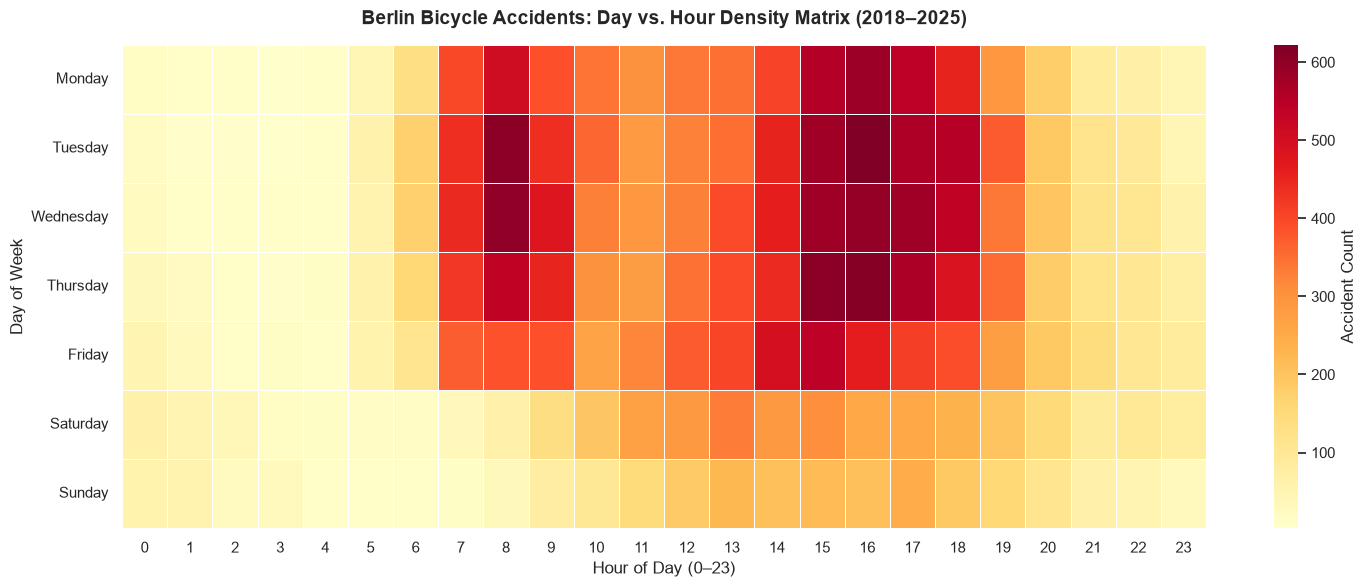

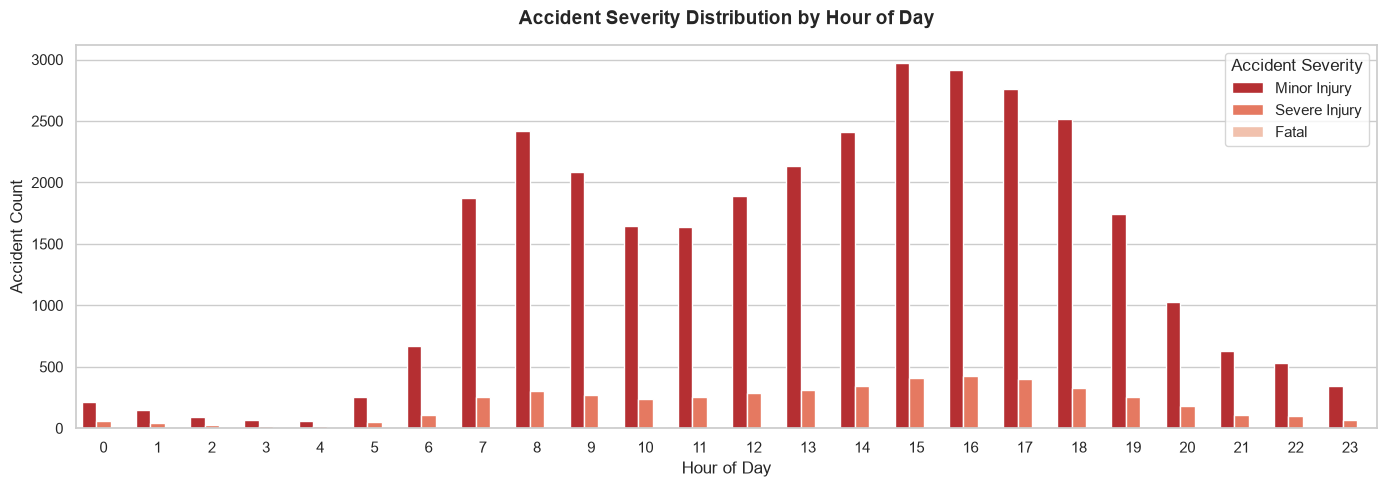

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ---------------------------------------------------------
# 1. ACCIDENT DENSITY HEATMAP (DAY OF WEEK x HOUR OF DAY)
# ---------------------------------------------------------
# Define logical ordering for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create pivot table (Rows: Days, Columns: Hours)
heatmap_data = df_berlin_rad_final.pivot_table(
    index='day_label', 
    columns='hour', 
    values='year', 
    aggfunc='count'
).reindex(day_order)

plt.figure(figsize=(15, 6))
sns.heatmap(
    heatmap_data, 
    cmap="YlOrRd", 
    annot=False, 
    linewidths=.5, 
    cbar_kws={'label': 'Accident Count'}
)

plt.title('Berlin Bicycle Accidents: Day vs. Hour Density Matrix (2018–2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. ACCIDENT COUNT AND SEVERITY DISTRIBUTION BY HOUR
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
sns.countplot(
    data=df_berlin_rad_final, 
    x='hour', 
    hue='severity_label', 
    palette='Reds_r'
)

plt.title('Accident Severity Distribution by Hour of Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Accident Count', fontsize=12)
plt.legend(title='Accident Severity', labels=['Minor Injury', 'Severe Injury', 'Fatal'])
plt.tight_layout()
plt.show()

---
## 4. Collision Partner Analysis <a id='4-collision'></a>

Each accident record flags which vehicle types were involved alongside the bicycle. We classify accidents by their collision partner to understand the primary risk sources.


                             collision_type  count  percentage
0                             Bicycle + Car  25736        67.8
1                              Bicycle Only   8317        21.9
2                      Bicycle + Pedestrian   2330         6.1
3                           Bicycle + Truck    733         1.9
4                      Bicycle + Motorcycle    653         1.7
5                Bicycle + Car + Pedestrian     94         0.2
6                Bicycle + Car + Motorcycle     44         0.1
7                     Bicycle + Car + Truck     31         0.1
8         Bicycle + Pedestrian + Motorcycle      4         0.0
9   Bicycle + Car + Pedestrian + Motorcycle      3         0.0
10             Bicycle + Motorcycle + Truck      1         0.0
11       Bicycle + Car + Motorcycle + Truck      1         0.0
12             Bicycle + Pedestrian + Truck      1         0.0


/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/931235823.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/931235823.py:36: UserWarning: 
The palette list has fewer values (8) than needed (13) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


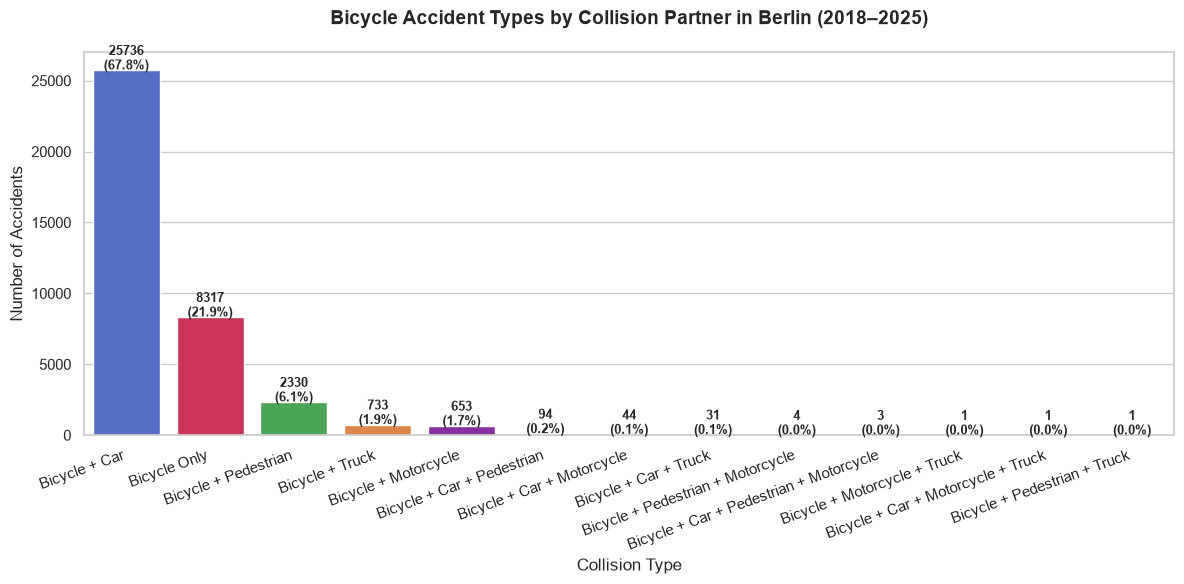

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kombinasyon sütunu oluştur
def get_combination(row):
    others = []
    if row['is_car'] == 1:
        others.append('Car')
    if row['is_pedestrian'] == 1:
        others.append('Pedestrian')
    if row['is_motorcycle'] == 1:
        others.append('Motorcycle')
    if row['is_truck'] == 1:
        others.append('Truck')
    if not others:
        return 'Bicycle Only'
    return 'Bicycle + ' + ' + '.join(others)

df_berlin_rad_final['collision_type'] = df_berlin_rad_final.apply(get_combination, axis=1)

# 2. Dağılım
combo_counts = (
    df_berlin_rad_final['collision_type']
    .value_counts()
    .reset_index()
)
combo_counts.columns = ['collision_type', 'count']
combo_counts['percentage'] = (combo_counts['count'] / len(df_berlin_rad_final) * 100).round(1)

print(combo_counts.to_string())

# 3. Grafik
plt.figure(figsize=(12, 6))
colors = ['#4363d8','#e6194b','#3cb44b','#f58231','#911eb4','#42d4f4','#f032e6','#bfef45']

ax = sns.barplot(
    data=combo_counts,
    x='collision_type',
    y='count',
    palette=colors[:len(combo_counts)]
)

# Yüzde ve sayı yaz
for i, row in combo_counts.iterrows():
    ax.text(i, row['count'] + 50, 
            f"{row['count']}\n({row['percentage']}%)", 
            ha='center', fontsize=9, fontweight='bold')

plt.title('Bicycle Accident Types by Collision Partner in Berlin (2018–2025)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Collision Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('berlin_collision_types.png', dpi=300, bbox_inches='tight')
plt.show()

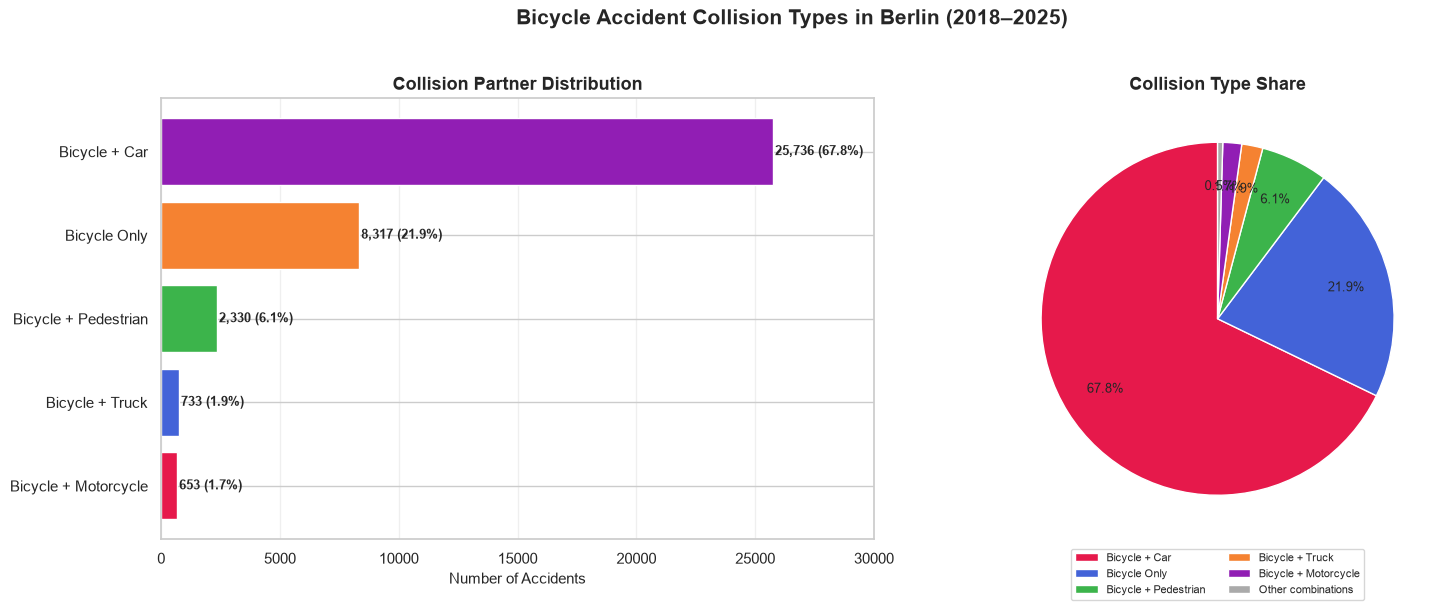

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece ana kombinasyonları al (>%0.5)
combo_main = combo_counts[combo_counts['percentage'] >= 0.5].copy()
combo_rest = combo_counts[combo_counts['percentage'] < 0.5]['count'].sum()

# Renk paleti
colors = ['#e6194b','#4363d8','#3cb44b','#f58231','#911eb4']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Bar chart
ax1 = axes[0]
bars = ax1.barh(combo_main['collision_type'][::-1], 
                combo_main['count'][::-1], 
                color=colors[:len(combo_main)])
for bar, (_, row) in zip(bars, combo_main[::-1].iterrows()):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"{row['count']:,} ({row['percentage']}%)",
             va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Number of Accidents', fontsize=11)
ax1.set_title('Collision Partner Distribution', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 30000)
ax1.grid(axis='x', alpha=0.3)

# Sağ: Pie chart
ax2 = axes[1]
pie_data = list(combo_main['count']) + [combo_rest]
pie_labels = list(combo_main['collision_type']) + ['Other combinations']
pie_colors = colors + ['#aaaaaa']
wedges, texts, autotexts = ax2.pie(
    pie_data,
    labels=None,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax2.legend(pie_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize=8, ncol=2)
ax2.set_title('Collision Type Share', fontsize=13, fontweight='bold')

plt.suptitle('Bicycle Accident Collision Types in Berlin (2018–2025)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_collision_types.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.1 Solo Crashes — Road & Light Conditions

**Hypothesis:** Bicycle-only crashes (no other vehicle) occur more often on wet or icy roads.

We test this by comparing road and light conditions between solo crashes and the full accident dataset.


In [11]:
## Filter: Bicycle Only accidents (no other vehicle involved)
df_bike_only = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle Only']

print(f"Bicycle Only accidents: {len(df_bike_only)}")

print(f"\nRoad conditions distribution:")
print(df_bike_only['road_label'].value_counts())

print(f"\nAs percentage:")
print((df_bike_only['road_label'].value_counts() / len(df_bike_only) * 100).round(1))

print("\n--- Comparison: All accidents ---")
print((df_berlin_rad_final['road_label'].value_counts() / len(df_berlin_rad_final) * 100).round(1))

Bicycle Only accidents: 8317

Road conditions distribution:
road_label
dry         2746
wet_damp     499
ice_snow      31
Name: count, dtype: int64

As percentage:
road_label
dry         33.0
wet_damp     6.0
ice_snow     0.4
Name: count, dtype: float64

--- Comparison: All accidents ---
road_label
dry         33.7
wet_damp     6.5
ice_snow     0.1
Name: count, dtype: float64


/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3602213283.py:87: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3602213283.py:87: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3602213283.py:87: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3602213283.py:87: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3602213283.py:88: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from font(s) Arial.
  plt.savefig('berlin_solo_crash_analysis.png', dpi=300, bbox_inches='tight')
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_77259/3

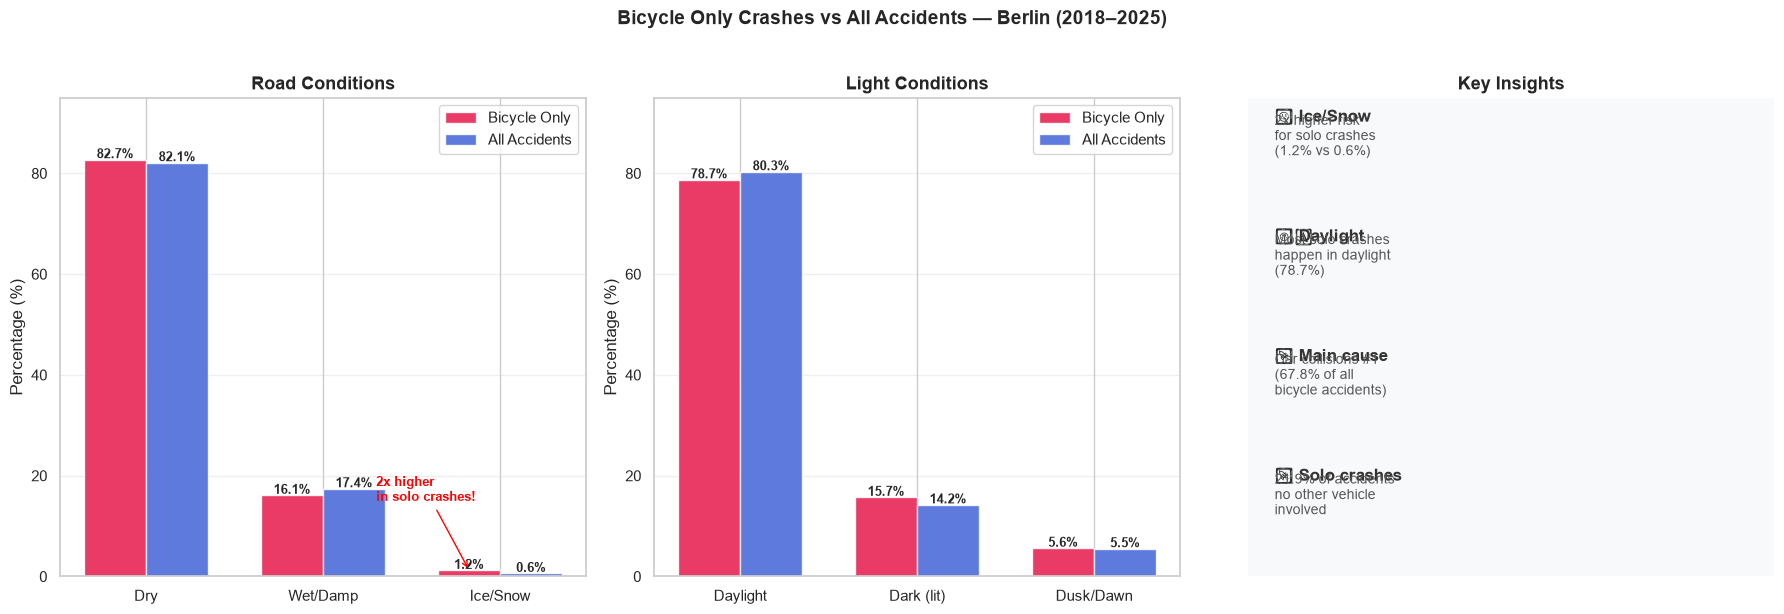

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categories = ['Dry', 'Wet/Damp', 'Ice/Snow']
bike_only_road = [82.7, 16.1, 1.2]
all_accidents_road = [82.1, 17.4, 0.6]

light_cats = ['Daylight', 'Dark (lit)', 'Dusk/Dawn']
bike_only_light = [78.7, 15.7, 5.6]
all_accidents_light = [80.3, 14.2, 5.5]

x = np.arange(len(categories))
width = 0.35

# 1. Road conditions comparison
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, bike_only_road, width, 
                label='Bicycle Only', color='#e6194b', alpha=0.85)
bars2 = ax1.bar(x + width/2, all_accidents_road, width, 
                label='All Accidents', color='#4363d8', alpha=0.85)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height()}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height()}%', ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Road Conditions', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 95)
ax1.grid(axis='y', alpha=0.3)

# Highlight ice/snow difference
ax1.annotate('2x higher\nin solo crashes!', 
             xy=(2 - width/2, 1.2), xytext=(1.3, 15),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=9, fontweight='bold')

# 2. Light conditions comparison
x2 = np.arange(len(light_cats))
ax2 = axes[1]
bars3 = ax2.bar(x2 - width/2, bike_only_light, width,
                label='Bicycle Only', color='#e6194b', alpha=0.85)
bars4 = ax2.bar(x2 + width/2, all_accidents_light, width,
                label='All Accidents', color='#4363d8', alpha=0.85)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height()}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height()}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(light_cats)
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Light Conditions', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 95)
ax2.grid(axis='y', alpha=0.3)

# 3. Summary insight card
ax3 = axes[2]
ax3.axis('off')
insights = [
    ("🧊 Ice/Snow", "2x higher risk\nfor solo crashes\n(1.2% vs 0.6%)"),
    ("☀️ Daylight", "Most solo crashes\nhappen in daylight\n(78.7%)"),
    ("🚗 Main cause", "Car collisions #1\n(67.8% of all\nbicycle accidents)"),
    ("🚴 Solo crashes", "21.9% of accidents\nno other vehicle\ninvolved"),
]
y_pos = 0.95
for icon_text, detail in insights:
    ax3.text(0.05, y_pos, icon_text, transform=ax3.transAxes,
             fontsize=12, fontweight='bold', color='#333333')
    ax3.text(0.05, y_pos - 0.07, detail, transform=ax3.transAxes,
             fontsize=10, color='#555555')
    y_pos -= 0.25

ax3.set_title('Key Insights', fontsize=13, fontweight='bold')
ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True, 
              color='#f8f9fa', transform=ax3.transAxes, zorder=0))

plt.suptitle('Bicycle Only Crashes vs All Accidents — Berlin (2018–2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_solo_crash_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Temporal Analysis <a id='5-temporal'></a>

### 5.1 Bicycle vs Car Accidents by Hour

We focus on the most common collision type (Bicycle + Car, 67.8%) and examine at which hours of the day accidents peak. Values represent **yearly averages** to account for differences in data volume across years.


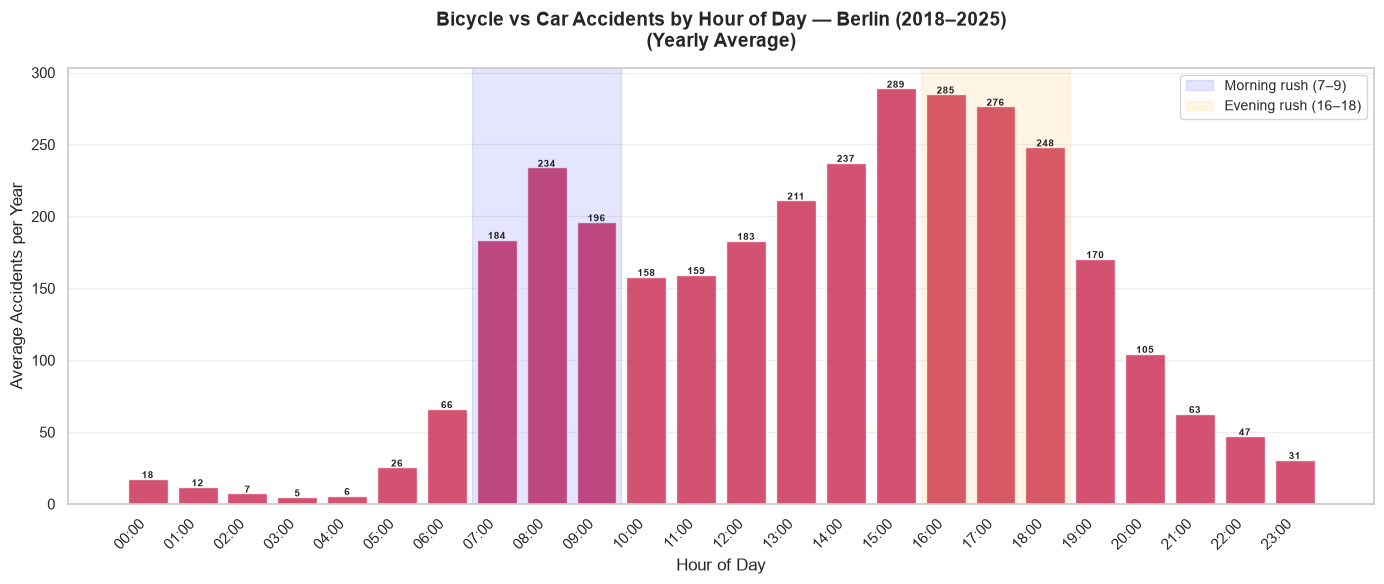

Top 5 most dangerous hours (yearly average):
 hour  count
   15  289.0
   16  284.9
   17  276.5
   18  248.2
   14  237.4


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter: Bicycle + Car accidents only
df_bike_car = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle + Car']

# Yearly average per hour
hourly_avg = (df_bike_car.groupby(['year', 'hour'])
              .size()
              .reset_index(name='count')
              .groupby('hour')['count']
              .mean()
              .round(1)
              .reset_index())

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=hourly_avg, x='hour', y='count', color='#e6194b', alpha=0.85)

# Add value labels on bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=7.5, fontweight='bold')

# Highlight rush hours
ax.axvspan(6.5, 9.5, alpha=0.1, color='blue', label='Morning rush (7–9)')
ax.axvspan(15.5, 18.5, alpha=0.1, color='orange', label='Evening rush (16–18)')

plt.title('Bicycle vs Car Accidents by Hour of Day — Berlin (2018–2025)\n(Yearly Average)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.xticks(range(24), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('berlin_bike_car_by_hour_avg.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 most dangerous hours (yearly average):")
print(hourly_avg.nlargest(5, 'count').to_string(index=False))

### 5.2 Accidents by Day of Week

**Hypothesis 1 — Monday effect:** Cyclists are less alert at the start of the week.  
**Hypothesis 2 — Friday effect:** Impatience before the weekend leads to more risk-taking.


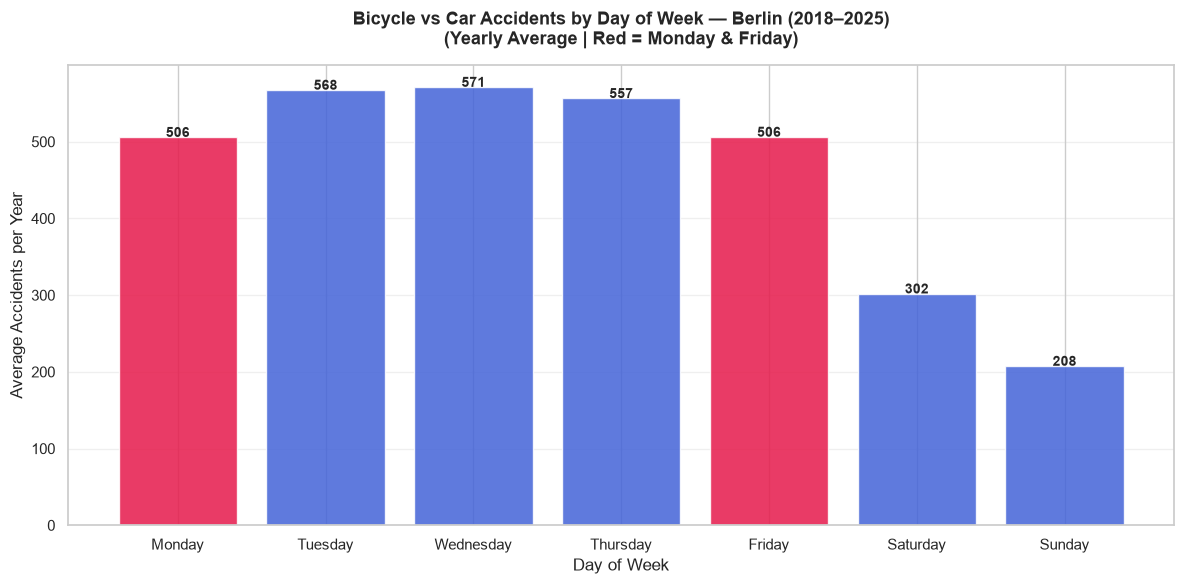

Average accidents by day of week:
 day_name  count
   Monday  505.9
  Tuesday  567.5
Wednesday  571.2
 Thursday  556.6
   Friday  506.2
 Saturday  301.9
   Sunday  207.6


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Day order and names (Germany: 1=Sunday, 2=Monday, ..., 7=Saturday)
day_order = [2, 3, 4, 5, 6, 7, 1]  # Monday → Sunday
day_names = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
             5:'Thursday', 6:'Friday', 7:'Saturday'}

# Bicycle + Car — yearly average per day
daily_avg = (df_bike_car.groupby(['year', 'day_of_week'])
             .size()
             .reset_index(name='count')
             .groupby('day_of_week')['count']
             .mean()
             .round(1)
             .reset_index())

daily_avg['day_name'] = daily_avg['day_of_week'].map(day_names)
daily_avg['day_name'] = pd.Categorical(
    daily_avg['day_name'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)
daily_avg = daily_avg.sort_values('day_name')

# Highlight Monday & Friday in red
colors = ['#e6194b' if d in ['Friday', 'Monday'] else '#4363d8'
          for d in daily_avg['day_name']]

plt.figure(figsize=(12, 6))
ax = plt.bar(daily_avg['day_name'], daily_avg['count'], color=colors, alpha=0.85)

# Add value labels on bars
for bar in ax:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Bicycle vs Car Accidents by Day of Week — Berlin (2018–2025)\n(Yearly Average | Red = Monday & Friday)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('berlin_bike_car_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average accidents by day of week:")
print(daily_avg[['day_name','count']].to_string(index=False))

### 5.3 Mid-Week Deep Dive (Tue–Thu)

Tuesday, Wednesday and Thursday consistently show the highest accident counts. We investigate whether this is driven by time-of-day patterns, severity differences, or light conditions.


In [19]:
# Hourly distribution: Tue–Wed–Thu vs Mon–Fri
df_bike_car['day_name'] = df_bike_car['day_of_week'].map(day_names)

mid_week   = df_bike_car[df_bike_car['day_name'].isin(['Tuesday','Wednesday','Thursday'])]
other_week = df_bike_car[df_bike_car['day_name'].isin(['Monday','Friday'])]

hourly_mid   = mid_week.groupby('hour').size() / 3    # average per day
hourly_other = other_week.groupby('hour').size() / 2

print("Hourly difference (Tue–Wed–Thu vs Mon–Fri):")
diff = (hourly_mid - hourly_other).round(1)
print(diff.sort_values(ascending=False).head(10))

Hourly difference (Tue–Wed–Thu vs Mon–Fri):
hour
8     93.7
18    71.8
17    60.2
7     56.0
16    55.5
19    46.7
15    40.8
9     40.0
6     30.2
10    11.5
dtype: float64


In [39]:
severity_by_day = df_bike_car.groupby(['day_name','severity_label']).size().unstack(fill_value=0)
severity_by_day['serious_rate'] = (severity_by_day['serious_injury'] / 
                                    severity_by_day.sum(axis=1) * 100).round(1)
print(severity_by_day[['serious_injury','fatal','serious_rate']])

severity_label  serious_injury  fatal  serious_rate
day_name                                           
Friday                     437      2          10.8
Monday                     398      6           9.8
Saturday                   288      3          11.9
Sunday                     224      2          13.5
Thursday                   449      4          10.1
Tuesday                    441      2           9.7
Wednesday                  461      4          10.1


---
## 6. District Risk Analysis <a id='6-district'></a>

We analyse accident counts and serious injury rates across Berlin's 12 districts. 

> **Key insight:** Total accident count and injury severity rate tell different stories — a district with many accidents is not necessarily the most dangerous one.


In [20]:
# District names (Berlin district codes)
district_names = {
    1: 'Mitte', 2: 'Friedrichshain-Kreuzberg', 3: 'Pankow',
    4: 'Charlottenburg-Wilmersdorf', 5: 'Spandau', 6: 'Steglitz-Zehlendorf',
    7: 'Tempelhof-Schöneberg', 8: 'Neukölln', 9: 'Treptow-Köpenick',
    10: 'Marzahn-Hellersdorf', 11: 'Lichtenberg', 12: 'Reinickendorf'
}

df_berlin_rad_final['district_name'] = df_berlin_rad_final['district_code'].map(district_names)

district_stats = (df_berlin_rad_final.groupby('district_name')
                  .agg(
                      total_accidents=('accident_severity', 'count'),
                      serious_fatal=('severity_label', lambda x: (x.isin(['serious_injury','fatal'])).sum())
                  )
                  .assign(serious_rate=lambda x: (x['serious_fatal']/x['total_accidents']*100).round(1))
                  .sort_values('total_accidents', ascending=False)
                  .reset_index())

print(district_stats.to_string(index=False))

             district_name  total_accidents  serious_fatal  serious_rate
                     Mitte             7338            781          10.6
  Friedrichshain-Kreuzberg             5124            552          10.8
                    Pankow             4205            578          13.7
Charlottenburg-Wilmersdorf             3983            494          12.4
      Tempelhof-Schöneberg             3001            411          13.7
          Treptow-Köpenick             2875            459          16.0
       Steglitz-Zehlendorf             2548            426          16.7
                  Neukölln             2360            231           9.8
               Lichtenberg             2032            296          14.6
             Reinickendorf             1674            249          14.9
       Marzahn-Hellersdorf             1419            236          16.6
                   Spandau             1389            217          15.6


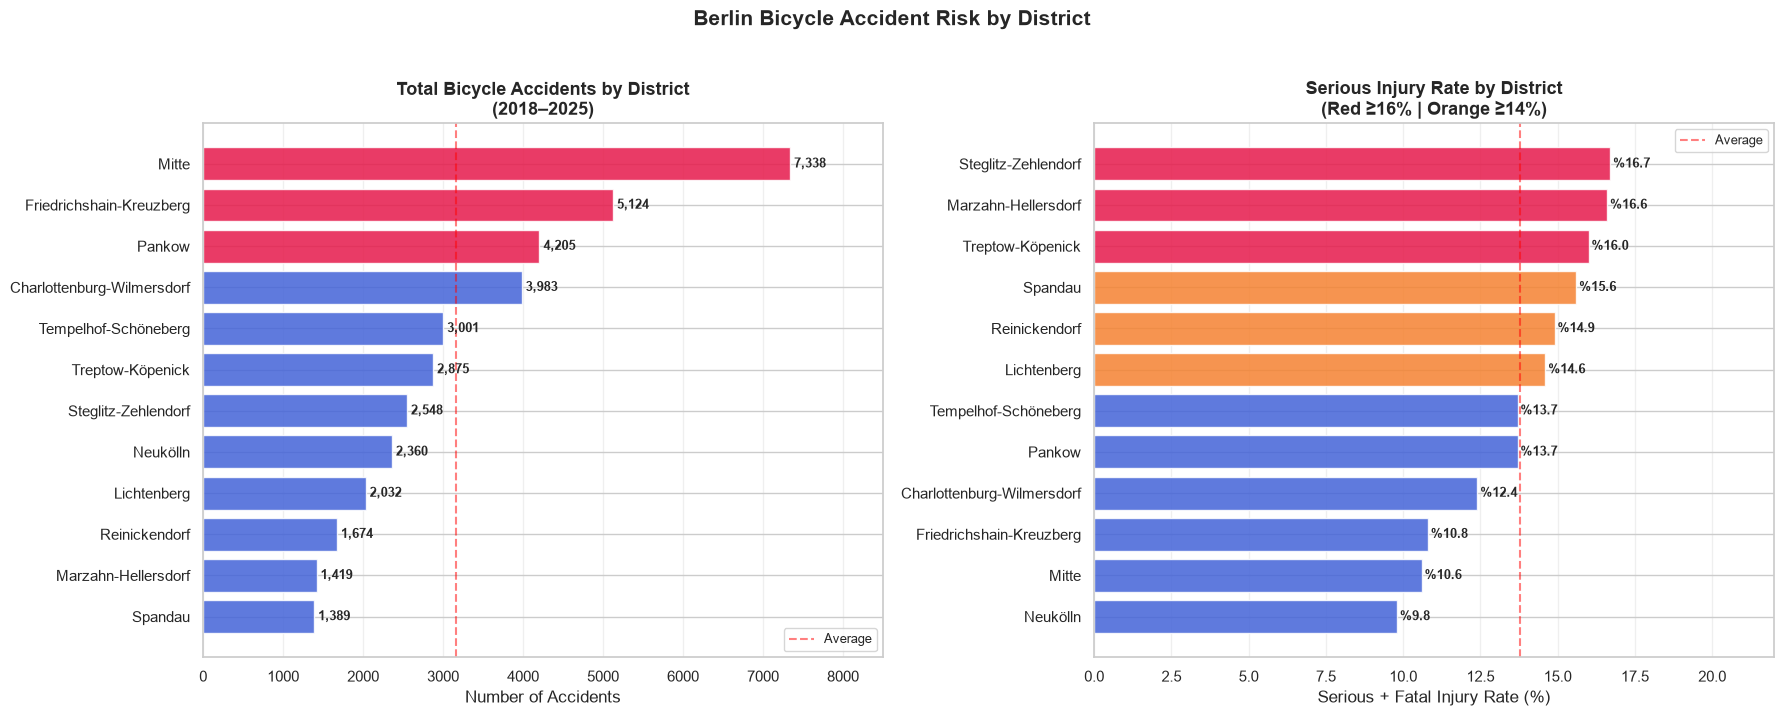

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol: Toplam kaza sayısı
district_sorted = district_stats.sort_values('total_accidents', ascending=True)
colors_total = ['#e6194b' if d in ['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow'] 
                else '#4363d8' for d in district_sorted['district_name']]

axes[0].barh(district_sorted['district_name'], 
             district_sorted['total_accidents'], 
             color=colors_total, alpha=0.85)
for i, (val, name) in enumerate(zip(district_sorted['total_accidents'], 
                                     district_sorted['district_name'])):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Bicycle Accidents by District\n(2018–2025)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
axes[0].set_xlim(0, 8500)
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=district_stats['total_accidents'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[0].legend(fontsize=9)

# Sağ: Ağır yaralanma oranı
district_severity = district_stats.sort_values('serious_rate', ascending=True)
colors_severity = ['#e6194b' if r >= 16.0 else '#f58231' if r >= 14.0 
                   else '#4363d8' for r in district_severity['serious_rate']]

axes[1].barh(district_severity['district_name'], 
             district_severity['serious_rate'], 
             color=colors_severity, alpha=0.85)
for i, val in enumerate(district_severity['serious_rate']):
    axes[1].text(val + 0.1, i, f'%{val}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Serious Injury Rate by District\n(Red ≥16% | Orange ≥14%)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Serious + Fatal Injury Rate (%)')
axes[1].set_xlim(0, 22)
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=district_stats['serious_rate'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[1].legend(fontsize=9)

plt.suptitle('Berlin Bicycle Accident Risk by District', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_district_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Geospatial Heatmap <a id='7-heatmap'></a>

An interactive heatmap weighted by accident severity (Fatal ×3 / Serious ×2 / Minor ×1) reveals the spatial distribution of high-risk zones across Berlin.


In [25]:
import folium
from folium.plugins import HeatMap
import pandas as pd

# 1. FIX AND CLEAN COORDINATES
df_berlin_rad_final["latitude"] = (
    df_berlin_rad_final["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_berlin_rad_final["longitude"] = (
    df_berlin_rad_final["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

geo_data = df_berlin_rad_final[["latitude", "longitude"]].dropna().copy()

# 2. FIND ACCIDENT HOTSPOTS (Grid Method)
# Rounding to 3 decimal places represents ~100m grid cells
geo_data["lat_grid"] = geo_data["latitude"].round(3)
geo_data["lon_grid"] = geo_data["longitude"].round(3)

# Top 10 most dangerous locations
hotspots = (
    geo_data.groupby(["lat_grid", "lon_grid"])
    .size()
    .reset_index(name="accident_count")
    .sort_values(by="accident_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Most Dangerous Locations:")
print(hotspots)

# 3. CREATE MAP
berlin_coords = [52.5200, 13.4050]
m = folium.Map(location=berlin_coords, zoom_start=12, tiles="OpenStreetMap")

# 4. ADD HEATMAP LAYER
heat_data = geo_data[["latitude", "longitude"]].values.tolist()
HeatMap(heat_data, radius=9, blur=10, max_zoom=13, min_opacity=0.3).add_to(m)

# 5. ADD MARKERS FOR TOP HOTSPOTS
for idx, row in hotspots.iterrows():
    # Top 3 locations in red, rest in orange
    color = "red" if idx < 3 else "orange"

    folium.Marker(
        location=[row["lat_grid"], row["lon_grid"]],
        popup=f"<b>Rank: #{idx+1}</b><br>Accidents: {row['accident_count']}",
        tooltip=f"Hotspot #{idx+1} ({row['accident_count']} accidents)",
        icon=folium.Icon(color=color, icon="warning", prefix="fa"),
    ).add_to(m)

# Save map
m.save("berlin_bike_accidents_heatmap.html")
m

Top 10 Most Dangerous Locations:
   lat_grid  lon_grid  accident_count
0    52.516    13.454             107
1    52.525    13.420              57
2    52.504    13.410              51
3    52.503    13.447              50
4    52.493    13.388              48
5    52.501    13.442              43
6    52.516    13.381              42
7    52.539    13.424              41
8    52.504    13.411              41
9    52.517    13.441              40


---
## Next Steps

- [ ] **Feature engineering** — rush hour flag, season, weekend/weekday
- [ ] **ML model** — XGBoost classifier for accident severity prediction
- [ ] **Route risk engine** — OSMnx + NetworkX for safe route recommendation
- [ ] **Streamlit dashboard** — interactive app combining all analyses
- [ ] **Claude API integration** — natural language route explanations
